# Complete Training Pipeline

## Drug Review Sentiment Classification with Pretrained Transformers

This notebook documents and executes the complete pipeline for training a custom classification head on top of a pretrained transformer model (e.g., RoBERTa, BERT) to classify drug reviews into three sentiment classes: **bad**, **medium**, and **good**.

### Approach
We use a **pretrained transformer backbone** (frozen or fine-tuned) and attach a **trainable classifier head** (MLP). The model is fine-tuned end-to-end on a balanced subset of the Drugs.com review dataset. This hybrid approach leverages the rich linguistic representations learned during pretraining while adapting the model to the specific task of sentiment classification.

### Pipeline Overview
1. **Preprocessing**: Load raw reviews, filter long texts, bucket ratings into 3 classes, balance via undersampling
2. **Model definition**: Load transformer backbone + custom classification head
3. **Training**: Fine-tune with differential learning rates, gradient clipping, learning rate scheduling
4. **Evaluation**: Per-class metrics, confusion analysis, generalization gap

---

## 1. Imports and Configuration

In [4]:
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
#import torch.nn as nn
#from torch.optim import AdamW
#from torch.utils.data import Dataset, DataLoader

#from transformers import AutoModel, AutoTokenizer
#from transformers import get_linear_schedule_with_warmup

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

print("All imports loaded successfully.")

All imports loaded successfully.


In [26]:
# ---------- Configuration ----------
SEED = 42
MODEL_NAME = "roberta-base"  # HuggingFace model ID
NUM_LABELS = 3
LABEL_MAP = {"bad": 0, "medium": 1, "good": 2}
LABEL_NAMES = ["bad", "medium", "good"]

# Training hyperparameters
EPOCHS = 3
BATCH_SIZE = 64
LR = 2e-5
MAX_LEN = 256
DROPOUT = 0.1
HEAD_LR_MULT = 10  # classifier head LR = LR * HEAD_LR_MULT
WARMUP_FRAC = 0.1
MAX_GRAD_NORM = 1.0
TEST_SIZE = 0.2

# Paths
RAW_DATA_PATH = Path("dataset/drugsCOM_raw.csv")
BALANCED_DATA_PATH = Path("dataset/drugsCOM_balanced.csv")
OUTPUT_DIR = Path("models") / MODEL_NAME.replace("/", "_")

# Plotting
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Model: {MODEL_NAME}")
print(f"Output: {OUTPUT_DIR}")

Using device: cpu
Model: roberta-base
Output: models\roberta-base


In [6]:
# ---------- Reproducibility ----------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


---
## 2. Data preprocessing

We load the raw Drugs.com review dataset, filter out reviews longer than 256 words (to respect transformer token limits), bucket the 1–10 ratings into three sentiment classes, and undersample to create a perfectly balanced dataset.

In [7]:
# Load raw data
df_raw = pd.read_csv(RAW_DATA_PATH)
print(f"Raw dataframe shape: {df_raw.shape}")
df_raw.head()

Raw dataframe shape: (215063, 8)


,Unnamed: 0,uniqueID,drugName,condition,review,rating,date,usefulCount
0,0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [12]:
# Review length statistics
review_lengths = df_raw["review"].apply(lambda x: len(str(x).split()))
print(f"Average length: {review_lengths.mean():.2f}")
print(f"95th percentile: {review_lengths.quantile(0.95):.2f}")
print(f"Max length: {review_lengths.max()}")

df_raw["review_length"] = review_lengths
df_filtered = df_raw[df_raw["review_length"] <= MAX_LEN].copy()
print(f"\nOriginal samples: {len(df_raw)}")
print(f"After filtering (<{MAX_LEN + 1} words): {len(df_filtered)}")
print(f"Removed: {len(df_raw) - len(df_filtered)}")

Average length: 84.68
95th percentile: 146.00
Max length: 1894

Original samples: 215063
After filtering (<257 words): 214864
Removed: 199


In [13]:
# Bucket ratings into 3 classes
# bad: rating < 4, medium: 4 ≤ rating ≤ 7, good: rating > 7
bins = [0, 4, 8, 11]
labels = ["bad", "medium", "good"]
df_filtered["label"] = pd.cut(
    df_filtered["rating"], bins=bins, labels=labels,
    right=False, include_lowest=True
)

counts = df_filtered["label"].value_counts()
print("Label distribution before balancing:")
for label in labels:
    print(f"  {label}: {counts[label]:,}")

min_count = counts.min()
print(f"\nMinority class sample count: {min_count:,}")

Label distribution before balancing:
  bad: 46,846
  medium: 38,383
  good: 129,635

Minority class sample count: 38,383


In [14]:
# Undersample each class to match the minority class
df_balanced = pd.concat([
    group.sample(n=min_count, random_state=SEED)
    for _, group in df_filtered.groupby("label", observed=True)
]).reset_index(drop=True)

print("Balanced class distribution:")
print(df_balanced["label"].value_counts())
print(f"\nTotal balanced samples: {len(df_balanced):,}")

# Save balanced dataset
df_balanced.to_csv(BALANCED_DATA_PATH, index=False)
print(f"Balanced dataset saved to {BALANCED_DATA_PATH}")

Balanced class distribution:
label
bad       38383
medium    38383
good      38383
Name: count, dtype: int64

Total balanced samples: 115,149
Balanced dataset saved to dataset\drugsCOM_balanced.csv


In [15]:
# Stratified train/test split
X = df_balanced["review"]
y = df_balanced["label"].map(LABEL_MAP)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")
print("\nClass distribution in Training set:")
print(y_train.value_counts(normalize=True).to_frame("proportion"))
print("\nClass distribution in Test set:")
print(y_test.value_counts(normalize=True).to_frame("proportion"))

Training set size: 92,119
Test set size: 23,030

Class distribution in Training set:
       proportion
label            
0        0.333341
1        0.333330
2        0.333330

Class distribution in Test set:
       proportion
label            
1        0.333348
2        0.333348
0        0.333304


---
## 3. Loading the Transformer Model

We load a pretrained transformer backbone and attach a lightweight trainable classification head:

**Architecture of the custom head:**
- Mean pooling over all token embeddings
- Linear(768 → 256) + ReLU + Dropout(0.1)
- Linear(256 → 3) → logits

The transformer backbone can be either frozen or fine-tuned. We use differential learning rates: a lower LR for the backbone (`LR = 2e-5`) and a 10× higher LR for the randomly initialised head (`LR = 2e-4`).

In [ ]:
class DrugReviewClassifier(nn.Module):
    def __init__(self, model_name: str, num_labels: int = 3, dropout: float = 0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def mean_pooling(self, token_embeddings, attention_mask):
        mask_expanded = attention_mask.unsqueeze(-1).float()
        return (token_embeddings * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.mean_pooling(outputs.last_hidden_state, attention_mask)
        logits = self.classifier(pooled)
        return logits

In [ ]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = DrugReviewClassifier(MODEL_NAME, num_labels=NUM_LABELS, dropout=DROPOUT).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

---
## 4. Training Pipeline Definition

### Dataset y DataLoader
Each sample is tokenized with padding and truncation to `MAX_LEN`.

In [ ]:
class DrugReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = DrugReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset = DrugReviewDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

### Optimizer, Scheduler, and Loss

We use **AdamW** with **differential learning rates**: a lower LR for the pretrained encoder and a 10× higher LR for the randomly initialised classifier head. A **linear warmup schedule** (10% of total steps) gradually increases the LR before decaying it linearly to zero.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    [
        {"params": model.encoder.parameters(), "lr": LR},
        {"params": model.classifier.parameters(), "lr": LR * HEAD_LR_MULT},
    ],
    weight_decay=0.01,
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_FRAC * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Encoder LR: {LR} | Head LR: {LR * HEAD_LR_MULT}")

### Training Loop and Validation

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, batch_losses, all_preds, all_labels = 0, [], [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        total_loss += loss_val
        batch_losses.append(loss_val)
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return batch_losses, avg_loss, macro_f1

In [ ]:
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, macro_f1, all_preds, all_labels

---
## 5. Training

The full training loop runs for `EPOCHS` epochs, tracking:
- Per-batch training loss
- Per-epoch training loss and macro F1
- Per-epoch validation loss and macro F1
- The best model (by validation F1) is saved for final evaluation.

In [16]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save config for reproducibility
config = {
    "model_name": MODEL_NAME,
    "data_path": str(BALANCED_DATA_PATH),
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "max_len": MAX_LEN,
    "dropout": DROPOUT,
}
(OUTPUT_DIR / "config.json").write_text(json.dumps(config, indent=2))

best_f1, best_state = 0, None
epoch_rows, batch_rows = [], []
global_step = 0

for epoch in range(1, EPOCHS + 1):
    train_batch_losses, train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )
    val_loss, val_f1, preds, gt = eval_epoch(model, test_loader, criterion, device)

    for bl in train_batch_losses:
        global_step += 1
        batch_rows.append({"step": global_step, "epoch": epoch, "loss": bl})

    epoch_rows.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_f1": train_f1,
        "val_f1": val_f1,
        "end_step": global_step,
    })

    pd.DataFrame(epoch_rows).to_csv(OUTPUT_DIR / "epoch_metrics.csv", index=False)
    pd.DataFrame(batch_rows).to_csv(OUTPUT_DIR / "batch_losses.csv", index=False)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f}  F1: {train_f1:.4f} | "
        f"Val loss: {val_loss:.4f}  F1: {val_f1:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  New best model (F1={best_f1:.4f})")

# Load best weights and save
model.load_state_dict(best_state)
torch.save(best_state, OUTPUT_DIR / "best_model.pt")
print(f"\nBest model saved to {OUTPUT_DIR / 'best_model.pt'}")

NameError: name 'train_epoch' is not defined

In [ ]:
# Final evaluation on test set
_, _, preds, gt = eval_epoch(model, test_loader, criterion, device)
report = classification_report(gt, preds, target_names=LABEL_NAMES)
(OUTPUT_DIR / "classification_report.txt").write_text(report)
print("Final Classification Report:")
print(report)

---
## 6. Evaluación y Resultados

Visualizations from the training run: loss trajectory, epoch dynamics, per-class performance, and summary metrics.

In [28]:
# Load saved metrics
epoch_df = pd.read_csv(OUTPUT_DIR / "epoch_metrics.csv")
batch_df = pd.read_csv(OUTPUT_DIR / "batch_losses.csv")

print(f"Epoch metrics:\n{epoch_df}")
print(f"\nBatch loss entries: {len(batch_df):,}")

Epoch metrics:
   epoch  train_loss  val_loss  train_f1    val_f1  end_step
0      1    0.639108  0.537445  0.712361  0.771159      1440
1      2    0.484409  0.490611  0.794697  0.796723      2880
2      3    0.400404  0.487210  0.836142  0.806170      4320

Batch loss entries: 4,320


### 6.1 Training Loss Trajectory (Batch Level)

Raw per-step loss (light) with 100-step rolling average (bold). Dashed lines mark epoch boundaries.

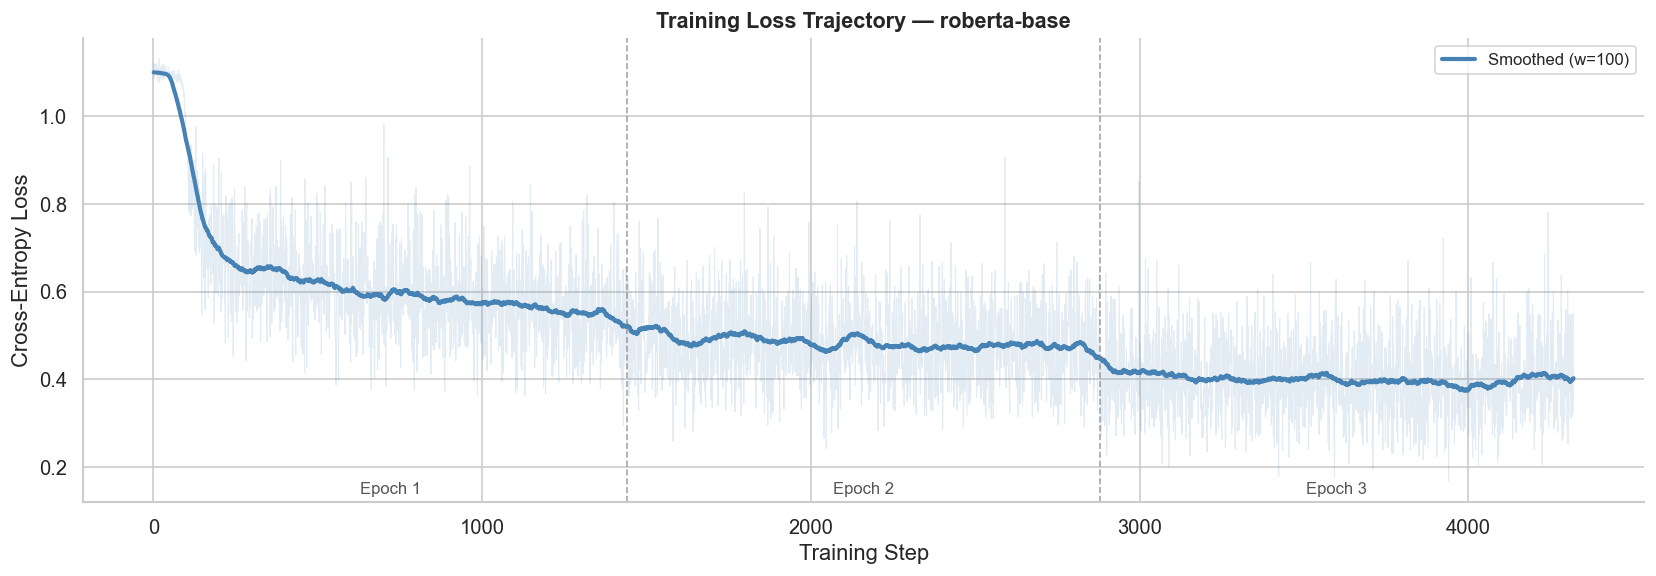

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))

steps = batch_df["step"].values
losses = batch_df["loss"].values.astype(float)
smoothed = pd.Series(losses).rolling(window=100, center=True, min_periods=1).mean().values

ax.plot(steps, losses, color="steelblue", alpha=0.15, linewidth=0.7)
ax.plot(steps, smoothed, color="steelblue", linewidth=2.5, label="Smoothed (w=100)")

for end in epoch_df["end_step"].values[:-1]:
    ax.axvline(end, color="gray", linestyle="--", linewidth=1.0, alpha=0.7)

boundaries = [0] + list(epoch_df["end_step"].values)
for i in range(EPOCHS):
    mid = (boundaries[i] + boundaries[i + 1]) / 2
    ax.text(mid, ax.get_ylim()[0] + 0.02, f"Epoch {i + 1}",
            ha="center", fontsize=10, color="#555",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none"))

ax.set_xlabel("Training Step")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title(f"Training Loss Trajectory — {MODEL_NAME}", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_batch_loss.png", bbox_inches="tight", dpi=150)
plt.show()

### 6.2 Epoch-Level Training Dynamics

Training vs. validation loss (top) and macro F1 (bottom) at each epoch. The shaded band shows the train–val gap.

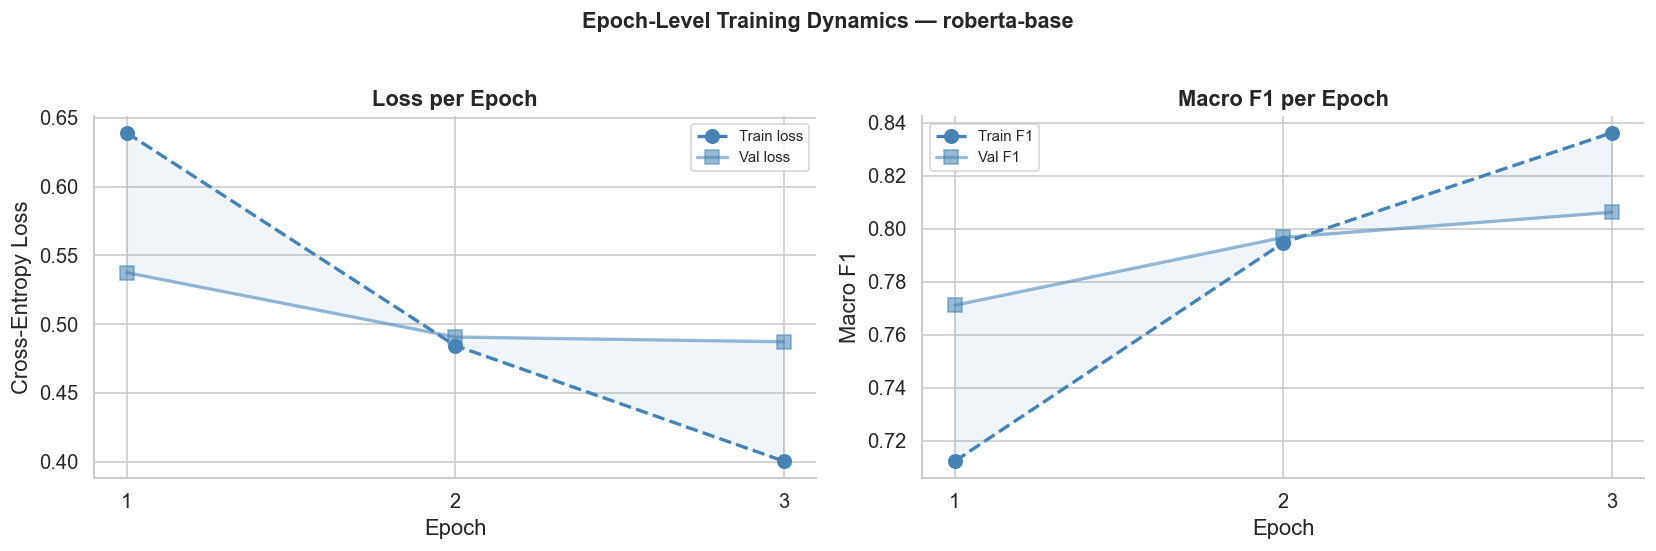

In [19]:
fig, (ax_loss, ax_f1) = plt.subplots(1, 2, figsize=(14, 4.5))

epochs = epoch_df["epoch"].values

# Loss
ax_loss.plot(epochs, epoch_df["train_loss"], "o--", color="steelblue", linewidth=2, markersize=8, label="Train loss")
ax_loss.plot(epochs, epoch_df["val_loss"], "s-", color="steelblue", linewidth=2, markersize=8, alpha=0.55, label="Val loss")
ax_loss.fill_between(epochs, epoch_df["train_loss"], epoch_df["val_loss"], color="steelblue", alpha=0.08)
ax_loss.set_ylabel("Cross-Entropy Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_title("Loss per Epoch", fontweight="bold")
ax_loss.set_xticks(range(1, EPOCHS + 1))
ax_loss.legend(fontsize=9)

# F1
ax_f1.plot(epochs, epoch_df["train_f1"], "o--", color="steelblue", linewidth=2, markersize=8, label="Train F1")
ax_f1.plot(epochs, epoch_df["val_f1"], "s-", color="steelblue", linewidth=2, markersize=8, alpha=0.55, label="Val F1")
ax_f1.fill_between(epochs, epoch_df["train_f1"], epoch_df["val_f1"], color="steelblue", alpha=0.08)
ax_f1.set_ylabel("Macro F1")
ax_f1.set_xlabel("Epoch")
ax_f1.set_title("Macro F1 per Epoch", fontweight="bold")
ax_f1.set_xticks(range(1, EPOCHS + 1))
ax_f1.legend(fontsize=9)

fig.suptitle(f"Epoch-Level Training Dynamics — {MODEL_NAME}", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_epoch_dynamics.png", bbox_inches="tight", dpi=150)
plt.show()

### 6.3 Generalisation Gap

The difference between training and validation F1 across epochs. A growing gap signals overfitting.

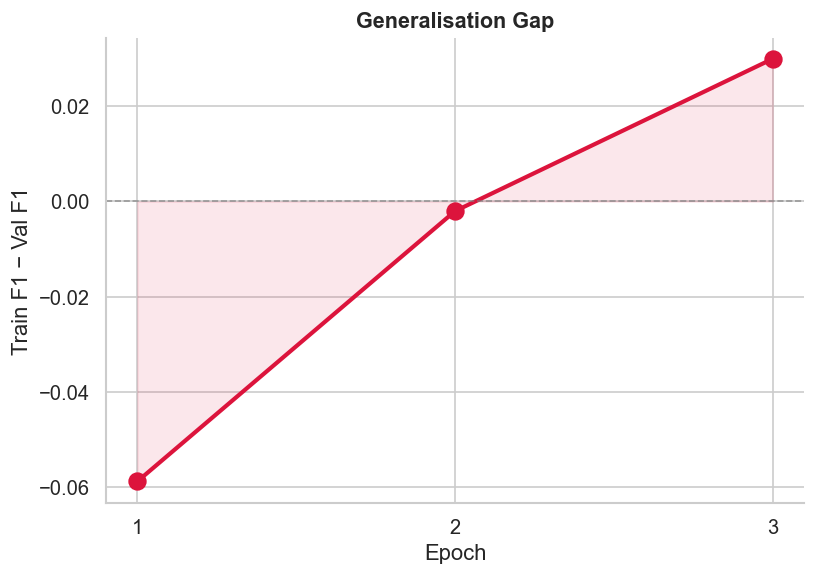

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

gap = epoch_df["train_f1"] - epoch_df["val_f1"]
ax.plot(epoch_df["epoch"], gap, "o-", color="crimson", linewidth=2.5, markersize=10)
ax.axhline(0, color="gray", linestyle="--", linewidth=1.0, alpha=0.7)
ax.fill_between(epoch_df["epoch"], 0, gap, color="crimson", alpha=0.1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train F1 − Val F1")
ax.set_title("Generalisation Gap", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, EPOCHS + 1))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_generalisation.png", bbox_inches="tight", dpi=150)
plt.show()

### 6.4 Per-Class Performance

F1 score broken down by sentiment class.

In [21]:
report_dict = classification_report(gt, preds, target_names=LABEL_NAMES, output_dict=True)

class_data = {cls: report_dict[cls] for cls in LABEL_NAMES}
accuracy = report_dict["accuracy"]
macro_f1 = report_dict["macro avg"]["f1-score"]

print(f"Test Accuracy: {accuracy:.3f}")
print(f"Macro F1: {macro_f1:.3f}")
print()
perf_df = pd.DataFrame(class_data).T
display(perf_df.round(3))

NameError: name 'gt' is not defined

In [ ]:
class_colors = {"bad": "#C0392B", "medium": "#F39C12", "good": "#27AE60"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["precision", "recall", "f1-score"]):
    mat = pd.DataFrame({cls: [class_data[cls][metric]] for cls in LABEL_NAMES}, index=[MODEL_NAME])
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="YlGnBu",
                vmin=0.60, vmax=0.92, linewidths=0.6, linecolor="white",
                annot_kws={"size": 14, "weight": "bold"},
                ax=ax, cbar=(metric == "f1-score"))
    ax.set_title(metric.capitalize(), fontsize=12, fontweight="bold")
    ax.set_xlabel("Class")

fig.suptitle(f"Per-Class Performance — {MODEL_NAME}", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# Grouped bar chart: F1 per class
fig, ax = plt.subplots(figsize=(8, 5))

f1_vals = [class_data[cls]["f1-score"] for cls in LABEL_NAMES]
bars = ax.bar(LABEL_NAMES, f1_vals, color=[class_colors[cls] for cls in LABEL_NAMES],
              alpha=0.82, edgecolor="white", linewidth=1.2, width=0.5)

for bar, v in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("F1 Score")
ax.set_title(f"Per-Class F1 — {MODEL_NAME}", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_perclass_f1.png", bbox_inches="tight", dpi=150)
plt.show()

### 6.5 Summary Table

In [22]:
summary = {
    "Model": MODEL_NAME,
    "Test Accuracy": round(accuracy, 4),
    "Macro F1": round(macro_f1, 4),
}
for cls in LABEL_NAMES:
    summary[f"F1 — {cls.capitalize()}"] = round(class_data[cls]["f1-score"], 4)
summary["Best Val F1"] = round(epoch_df["val_f1"].max(), 4)
summary["Final Train F1"] = round(epoch_df["train_f1"].iloc[-1], 4)

summary_df = pd.DataFrame([summary]).set_index("Model")
display(summary_df.style.format("{:.4f}").set_caption("Test Set Performance Summary"))

NameError: name 'accuracy' is not defined

---
## 7. Conclusions

### Summary of Results

In this notebook we executed the complete drug review sentiment classification pipeline using a pretrained transformer (`roberta-base`) with a trainable classification head. The process included:

1. **Preprocessing**: filtering long reviews, bucketing into 3 classes (bad/medium/good), and balancing via undersampling.
2. **Training**: 3 epochs with differential learning rates (encoder: 2e-5, head: 2e-4), linear warmup, and gradient clipping.
3. **Evaluation**: per-class and global metrics, with visualisation of training dynamics.

**Note on experimental models**:
The repository includes experimentation with 4 models — `Bio_ClinicalBERT`, `roberta-base`, `deberta-v3-base`, and `sentiment-roberta-large-english` — evaluated in `results.ipynb`. The best performance was obtained with **Sentiment-RoBERTa-Large** (82% accuracy, 0.83 macro F1), since its sentiment-oriented pretraining aligns directly with the task. This notebook uses `roberta-base` as the default model for its balance between computational cost and performance.

**Hardest class**: `medium` (ratings 4–7) consistently shows the lowest F1, as these reviews contain ambiguous opinions at the boundary between positive and negative sentiment.